# **Seminar 5 — Federated Learning**

1. **Part I: ML model definition**
    
    - The dataset is known to you, so you are already able to load and process it as needed.
    
    - Focus on the ML model that you will train collaboratively through FL.
    
    - You are free to choose the model architecture (you can also work with the linear regressor from Seminar 2).
    
    - Remember that we are dealing with a classification problem, which may have implications in your model architecture (e.g., selected loss function, type of activations).

2. **Part II: Preparation of the FL setting**
    - Define a central orchestrator (or parameter server) which must perform the following operations:
        
        1. Initialize a global ML model, $ω(t = 0)$
        
        2. Select a subset of clients S ⊆ K to participate in the current training iteration.
        
        3. Send the global model to the clients, which is retrained by the clients using their local datasets $(D^k, ∀k ∈ S)$.
        
        4. Retrieve the individual models $ω_k(t)$, $∀k ∈ S$ from the selected clients.
        
        5. Aggregate the individual contributions to update the global model, $ω(t+1)$. To perform model aggregation, consider using FedAvg, whereby a weighted average of the model weights is calculated. The weights ($α$) are given by the total share of data of each client: $\alpha_k = \frac{|D^k|}{\sum_{k \in S} |D^k|}, \quad k \in S$
        
        6. Repeat steps 2-5 until convergence.

3. **Part III: Collaborative training of the model**
    
    - Define the required hyperparameters to collaboratively train your ML model (e.g., number of FL iterations, number of epochs for local model training, batch size, etc.).
    
    - Train the model using FL using the training dataset (client_k_features.csv and client_k_labels.csv).
    
    - Evaluate the model using the test data partition (test_features.csv and test_labels.csv).

#### **Core libraries**

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# **Part I**

#### **1. Model Architecture Definition**

Initially, a multiclass Logistic Regression model was used. A linear model computes flat decision lines to separate vectors:
$$Z=XW+b$$

Because radio wave interactions (multipath reflections, phase alterations, and shadowing effects) are non-linear, drawing straight boundaries topped the accuracy at a  ceiling of 0.39.

To break this barrier, we introduced a Multi-Layer Perceptron (MLP) with a hidden layer of 64 units.

The forward pass now consists of two stages:

- Hidden Layer Mapping: Maps the raw 270 features into a 64-dimensional feature space, passing through a ReLU non-linearity to allow the model to catch complex variations:
$$Z_1​=XW_1​+b_1​,\ A_1​=max(0,Z_1​)$$

- Output Classification Layer: Multiplies the hidden features by a second weight matrix to map them into the 12 target classes, via a Softmax activation function to generate absolute class probabilities:
$$Z_2​=A_1​W_2​+b_2​,\ A_2​=Softmax(Z_2​)$$

In [ ]:
N_CLASSES  = 12   # poses: wave, push, crouch, sitdown, bend, ...
N_FEATURES = 270  # flattened CSI matrix: 30×3×3

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Helper function for ReLU activation
def relu(z):
    return np.maximum(0, z)

# Helper function for ReLU derivative
def relu_deriv(z):
    return (z > 0).astype(float)

def predict_mlp(X, W1, b1, W2, b2):
    # Forward pass
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    probs = softmax(Z2)
    return np.argmax(probs, axis=1) + 1

# **Part II**

#### **1. Central Orchestrator (Parameter Server)**

The parameter server is the coordinator of the FL process. It never sees any raw data, it only works with model weights. 

Therefore, its responsibilities are:
1. Hold and initialize the global model weights
2. Select which clients participate in each round
3. Distribute the global weights to selected clients
4. Collect the locally-trained weights from clients
5. Aggregate them using **FedAvg**: a weighted average proportional to each client's dataset size:
$$W_{global}​=\sum_{k=1}^{K} \frac{n_k}{N_{total​​}}​W_k​$$

In [78]:
class ParameterServerMLP:
    def __init__(self, n_features, n_hidden, n_classes, random_state=42):
        np.random.seed(random_state)
        # He Initialization for ReLU (helps gradients flow better)
        self.W1 = np.random.randn(n_features, n_hidden) * np.sqrt(2. / n_features)
        self.b1 = np.zeros(n_hidden)
        
        # Standard initialization for output layer
        self.W2 = np.random.randn(n_hidden, n_classes) * 0.1
        self.b2 = np.zeros(n_classes)
        
    def select_clients(self, client_ids, fraction=1.0):
        num_selected = max(1, int(fraction * len(client_ids)))
        return np.random.choice(client_ids, num_selected, replace=False)
    
    def get_global_weights(self):
        return self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy()
    
    def aggregate(self, client_updates, client_sizes):
        total_samples = sum(client_sizes)
        
        # Initialize empty arrays
        new_W1 = np.zeros_like(self.W1)
        new_b1 = np.zeros_like(self.b1)
        new_W2 = np.zeros_like(self.W2)
        new_b2 = np.zeros_like(self.b2)
        
        # FedAvg
        for (W1, b1, W2, b2), n in zip(client_updates, client_sizes):
            weight = n / total_samples
            new_W1 += weight * W1
            new_b1 += weight * b1
            new_W2 += weight * W2
            new_b2 += weight * b2
            
        self.W1, self.b1, self.W2, self.b2 = new_W1, new_b1, new_W2, new_b2

print("ParameterServer class defined.")

ParameterServer class defined.


#### **2. Client Implementation**

When a client checks in, it starts from the current global model and trains locally on mini-batches of 32 samples. The problem is that training too long on skewed local data pulls the model away from the global consensus, a known issue called Client Drift. To counter this, we use FedProx, which adds a small penalty that keeps local updates from wandering too far:
$$Loss_{FedProx}​=Loss_{CrossEntropy}​+\frac{μ​}{2}​ ∥W−Wglobal​∥^2$$

In [ ]:
class ClientMLP:
    def __init__(self, client_id, X, y, learning_rate=0.01):
        self.client_id = client_id
        self.X = X
        self.y = y
        self.n = len(y)
        self.learning_rate = learning_rate
        
    def local_train(self, g_W1, g_b1, g_W2, g_b2, local_epochs, mu=0.01, batch_size=32):
        # Warm start from global weights
        W1, b1 = g_W1.copy(), g_b1.copy()
        W2, b2 = g_W2.copy(), g_b2.copy()

        # One-hot encode
        Y_onehot = np.zeros((self.n, N_CLASSES))
        for i, label in enumerate(self.y):
            Y_onehot[i, int(label) - 1] = 1  

        for _ in range(local_epochs):
            # Shuffle data for mini-batches
            indices = np.random.permutation(self.n)
            X_shuffled = self.X[indices]
            Y_shuffled = Y_onehot[indices]
            
            for start_idx in range(0, self.n, batch_size):
                end_idx = start_idx + batch_size
                X_batch = X_shuffled[start_idx:end_idx]
                Y_batch = Y_shuffled[start_idx:end_idx]
                m = X_batch.shape[0]

                # --- FORWARD PASS ---
                Z1 = X_batch @ W1 + b1
                A1 = relu(Z1)
                Z2 = A1 @ W2 + b2
                A2 = softmax(Z2)

                # --- BACKWARD PASS ---
                # 1. Output Layer Gradients
                dZ2 = A2 - Y_batch
                dW2 = (A1.T @ dZ2) / m
                db2 = np.sum(dZ2, axis=0) / m
                
                # 2. Hidden Layer Gradients
                dA1 = dZ2 @ W2.T
                dZ1 = dA1 * relu_deriv(Z1)
                dW1 = (X_batch.T @ dZ1) / m
                db1 = np.sum(dZ1, axis=0) / m

                # --- FEDPROX PENALTY ---
                dW2 += mu * (W2 - g_W2)
                db2 += mu * (b2 - g_b2)
                dW1 += mu * (W1 - g_W1)
                db1 += mu * (b1 - g_b1)

                # --- UPDATE WEIGHTS ---
                W1 -= self.learning_rate * dW1
                b1 -= self.learning_rate * db1
                W2 -= self.learning_rate * dW2
                b2 -= self.learning_rate * db2

        return (W1, b1, W2, b2)

# **Part III**

#### **1. Hyperparameter Definition**

In [ ]:
NUM_CLIENTS = 10     # total number of clients (K)
NUM_ROUNDS = 100    # number of FL communication rounds (T)
CLIENT_FRACTION = 1.0    # fraction of clients selected each round (1.0 = all)
LOCAL_EPOCHS = 10     # number of gradient descent steps per client per round
LEARNING_RATE = 0.1    # step size for local gradient descent
RANDOM_STATE = 42    

print("Hyperparameters set:")
print(f"  Clients per round : {int(NUM_CLIENTS * CLIENT_FRACTION)} / {NUM_CLIENTS}")
print(f"  FL rounds         : {NUM_ROUNDS}")
print(f"  Local epochs      : {LOCAL_EPOCHS}")
print(f"  Learning rate     : {LEARNING_RATE}")

Hyperparameters set:
  Clients per round : 10 / 10
  FL rounds         : 100
  Local epochs      : 10
  Learning rate     : 0.1


#### **2. Data Loading**

We load each client's local dataset and the shared test set. Note that the label CSVs are stored as a single row (wide format), so we transpose them to get a column vector.

In [ ]:
BASE_PATH = "." 

def load_client_data(client_id, base_path=BASE_PATH):
    # Load features and labels for a given client 
    X = pd.read_csv(f"{base_path}/client_datasets/client_{client_id}_features.csv",header=None).values
    y = pd.read_csv(f"{base_path}/client_datasets/client_{client_id}_labels.csv",header=None).T.values.ravel()
    return X, y

def load_test_data(base_path=BASE_PATH):
    # Load the shared test dataset
    X = pd.read_csv(f"{base_path}/test_features.csv", header=None).values
    y = pd.read_csv(f"{base_path}/test_labels.csv",   header=None).T.values.ravel()
    return X, y

all_X = []
for i in range(1, NUM_CLIENTS + 1):
    X, _ = load_client_data(i)  
    all_X.append(X)

global_scaler = StandardScaler()
global_scaler.fit(np.vstack(all_X))

# 2. Instantiate clients with PRE-SCALED data
clients = {}
for i in range(1, NUM_CLIENTS + 1):
    X, y = load_client_data(i)
    X_scaled = global_scaler.transform(X) 
    clients[i] = ClientMLP(i, X_scaled, y, learning_rate=0.01)

# 3. Load and scale test data using the SAME global scaler
X_test, y_test = load_test_data() 
X_test_scaled = global_scaler.transform(X_test)
print(f"\nTest set: {len(y_test)} samples, classes: {sorted(set(y_test))}")


Test set: 500 samples, classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


####  **3. Federated Learning Training**

In [ ]:
N_HIDDEN = 64  # The size of our new hidden layer

def run_mlp_fl_experiment(learning_rate, local_epochs, mu=0.01, num_rounds=50):
    server = ParameterServerMLP(n_features=N_FEATURES, n_hidden=N_HIDDEN, n_classes=N_CLASSES)
    
    for c_id in clients:
        clients[c_id].learning_rate = learning_rate
        
    test_accuracies = []
    
    for t in range(num_rounds):
        all_ids = list(clients.keys())
        selected_ids = server.select_clients(all_ids, fraction=1.0)
        
        # Get all 4 parameter matrices
        g_W1, g_b1, g_W2, g_b2 = server.get_global_weights()
        
        client_updates = []
        client_sizes = []
        
        for c_id in selected_ids:
            client = clients[c_id]
            # Returns tuple of 4 updated matrices
            updated_weights = client.local_train(g_W1, g_b1, g_W2, g_b2, local_epochs, mu=mu)
            
            client_updates.append(updated_weights)
            client_sizes.append(client.n)
        
        server.aggregate(client_updates, client_sizes)
        
        # Evaluation
        curr_W1, curr_b1, curr_W2, curr_b2 = server.get_global_weights()
        y_pred = predict_mlp(X_test_scaled, curr_W1, curr_b1, curr_W2, curr_b2)
        acc = accuracy_score(y_test, y_pred)
        test_accuracies.append(acc)
        
    return test_accuracies

#### **4. Model Evaluation**

To evaluate the model, we perform an experiment with different hyperparameters, in order to find the best combination:
- Learning rate = 0.01, Epochs = 5, µ = 0.0

- Learning rate = 0.01, Epochs = 15, µ = 0.0

- Learning rate = 0.01, Epochs = 15, µ = 0.05

- Learning rate = 0.05, Epochs = 10, µ = 0.1 

Running MLP FL with LR=0.01, Epochs=5, µ=0.0...
Running MLP FL with LR=0.01, Epochs=15, µ=0.0...
Running MLP FL with LR=0.01, Epochs=15, µ=0.05...
Running MLP FL with LR=0.05, Epochs=10, µ=0.1...


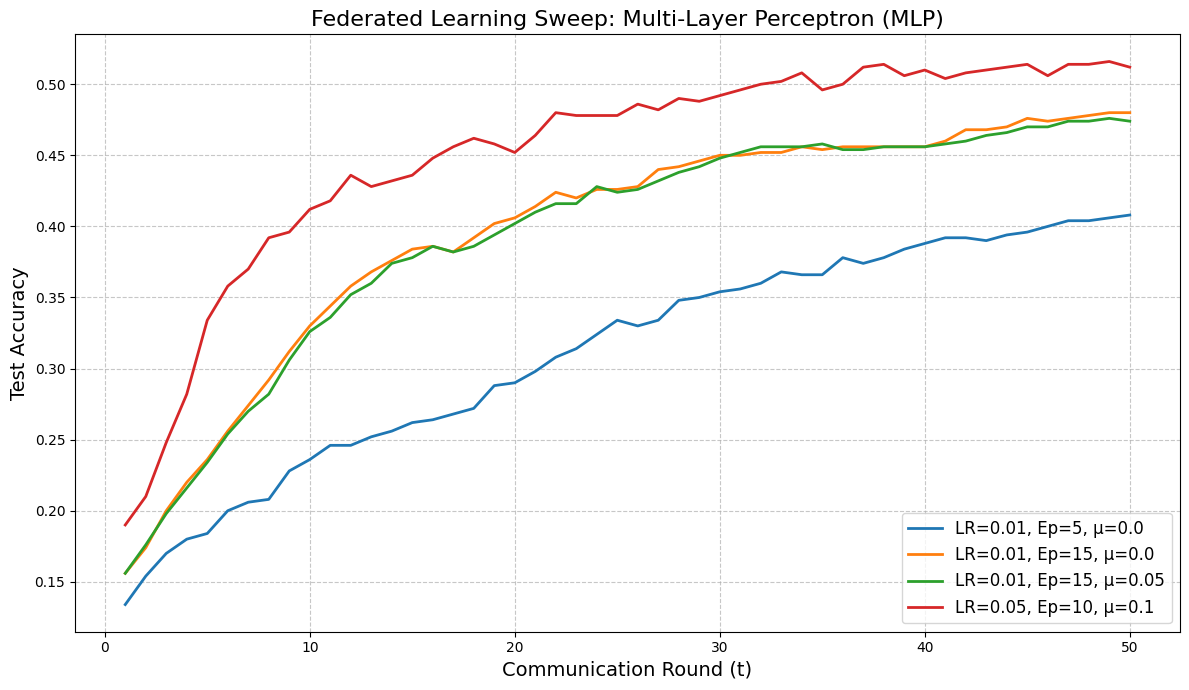

In [83]:
mlp_hyperparam_grid = [
    {'lr': 0.01, 'epochs': 5,  'mu': 0.0},   # Standard FedAvg (Low local epochs)
    {'lr': 0.01, 'epochs': 15, 'mu': 0.0},   # Standard FedAvg (Higher epochs, risk of drift)
    {'lr': 0.01, 'epochs': 15, 'mu': 0.05},  # FedProx active (Moderate protection)
    {'lr': 0.05, 'epochs': 10, 'mu': 0.1}    # Higher learning rate with strong FedProx constraint
]

# Total rounds for the experiment
SWEEP_ROUNDS = 50

plt.figure(figsize=(12, 7))

# 3. Run the evaluation sweep
for params in mlp_hyperparam_grid:
    print(f"Running MLP FL with LR={params['lr']}, Epochs={params['epochs']}, µ={params['mu']}...")
    
    # Run the custom MLP federated training loop
    acc_history = run_mlp_fl_experiment(
        learning_rate=params['lr'], 
        local_epochs=params['epochs'], 
        mu=params['mu'],
        num_rounds=SWEEP_ROUNDS
    )
    
    label = f"LR={params['lr']}, Ep={params['epochs']}, µ={params['mu']}"
    plt.plot(range(1, SWEEP_ROUNDS + 1), acc_history, linewidth=2, label=label)

# 4. Plot formatting and display
plt.title('Federated Learning Sweep: Multi-Layer Perceptron (MLP)', fontsize=16)
plt.xlabel('Communication Round (t)', fontsize=14)
plt.ylabel('Test Accuracy', fontsize=14)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Analysis**

The grid sweep gives a clear picture of how each configuration behaves:

- `LR=0.01, Ep=5, µ=0.0`:
By restricting local training to just 5 epochs, the local weights never travel far enough to drift. However, because the learning rate is low (0.01) and there's a few epochs, it learns very slowly. It converges steadily, just not efficiently.

- `LR=0.01, Ep=15, µ=0.0` :
Increasing training to 15 local epochs per round allows clients to extract more value from their data patterns early on. However, because μ=0.0, since there is no regularization, the local updates start fighting the global model. This makes the progress stall and make the training curve become volatile.

- `LR=0.01, Ep=15, µ=0.05` :
By simply switching the constraint coefficient to μ=0.05, the system's stabilizes significantly. The lines smooth out over the later communication rounds. The penalty restrains the clients from over-tuning to their restricted set of 2–8 local poses, forcing them to find a general compromise.

- `LR=0.05, Ep=10, µ=0.1`:
This is the sweet spot. A higher learning rate lets the model take meaningful update steps, 10 local epochs provide enough training without excessive drift, and the stronger regularization keeps clients anchored to the global model while still allowing them to learn. Together, these allow the model to build the non-linear decision boundaries needed to distinguish poses from Wi-Fi patterns.

To get more information, we train the model again with the best hyperparameters and generate a classification report and confusion matrix

Initializing final training with optimized hyperparameters...
Training complete. Extracting final weights for analytics...

             FINAL FEDERATED MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Pose 1       0.73      0.81      0.77        57
      Pose 2       0.48      0.25      0.33        51
      Pose 3       0.00      0.00      0.00        56
      Pose 4       0.51      0.38      0.44        47
      Pose 5       0.74      0.86      0.80        50
      Pose 6       0.48      0.87      0.62        47
      Pose 7       0.55      0.16      0.25        37
      Pose 8       0.26      0.59      0.36        17
      Pose 9       0.31      0.92      0.46        12
     Pose 10       0.68      0.40      0.50        63
     Pose 11       0.47      0.73      0.57        52
     Pose 12       0.17      0.45      0.25        11

    accuracy                           0.51       500
   macro avg       0.45      0.54      0.45       500
weighte

/Users/alexrogermoya/Desktop/Uni/Curs 25-26/3r trim/AAX/AAX_Projects/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexrogermoya/Desktop/Uni/Curs 25-26/3r trim/AAX/AAX_Projects/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexrogermoya/Desktop/Uni/Curs 25-26/3r trim/AAX/AAX_Projects/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

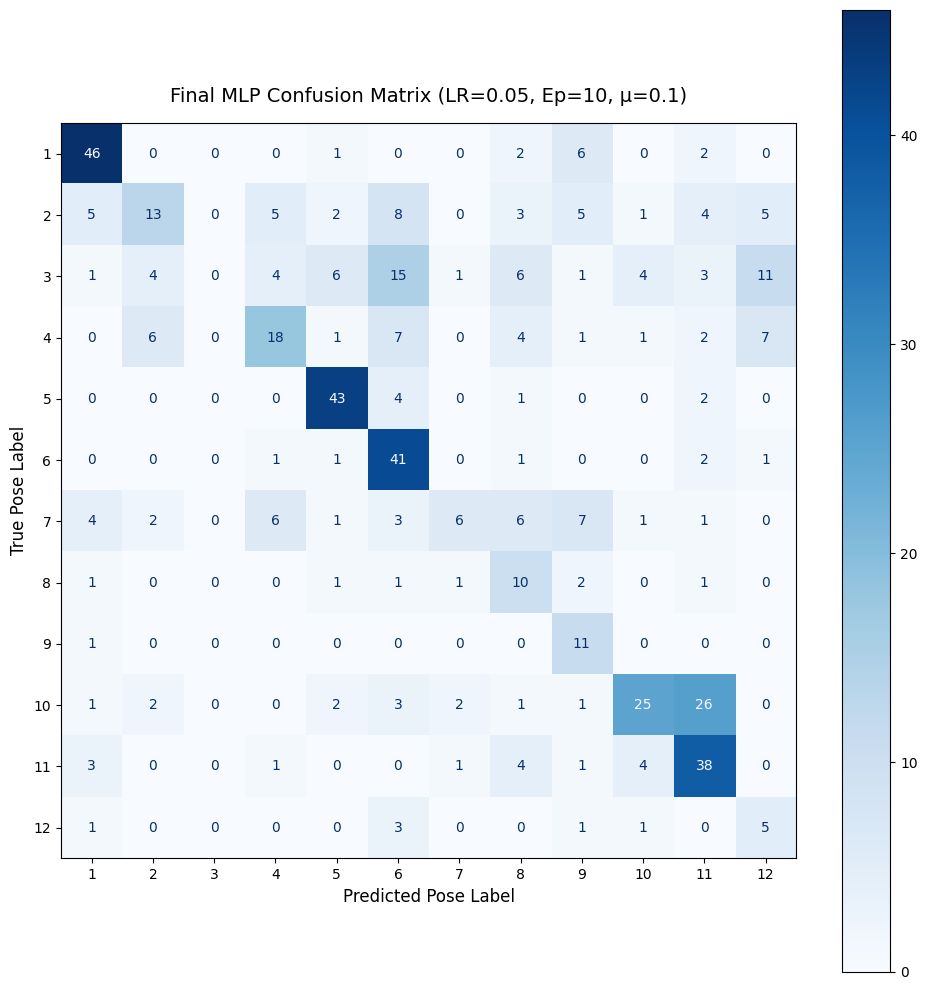

In [ ]:
# 1. Set the winning hyperparameters discovered in the sweep
BEST_LR = 0.05
BEST_EPOCHS = 10
BEST_MU = 0.1
FINAL_ROUNDS = 50

print("Initializing final training with optimized hyperparameters...")
server_final = ParameterServerMLP(n_features=N_FEATURES, n_hidden=64, n_classes=N_CLASSES)

# Ensure clients are set to the best learning rate
for c_id in clients:
    clients[c_id].learning_rate = BEST_LR

# 2. Run final training loop to converge on the optimal weights
for r in range(FINAL_ROUNDS):
    all_ids = list(clients.keys())
    selected_ids = server_final.select_clients(all_ids, fraction=1.0)
    g_W1, g_b1, g_W2, g_b2 = server_final.get_global_weights()
    
    client_updates = []
    client_sizes = []
    
    for c_id in selected_ids:
        W_tuple = clients[c_id].local_train(g_W1, g_b1, g_W2, g_b2, local_epochs=BEST_EPOCHS, mu=BEST_MU)
        client_updates.append(W_tuple)
        client_sizes.append(clients[c_id].n)
        
    server_final.aggregate(client_updates, client_sizes)

print("Training complete. Extracting final weights for analytics...")
final_W1, final_b1, final_W2, final_b2 = server_final.get_global_weights()

# 3. Generate predictions on the unseen test set
y_pred_final = predict_mlp(X_test_scaled, final_W1, final_b1, final_W2, final_b2)

# 4. Generate & Display Classification Report
print("\n" + "="*60)
print("             FINAL FEDERATED MODEL CLASSIFICATION REPORT")
print("="*60)
# Poses are classes 1 through 12
pose_names = [f"Pose {i}" for i in range(1, 13)] 
print(classification_report(y_test, y_pred_final, target_names=pose_names))
print("="*60)

# 5. Generate & Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(1, 13))

disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title(f'Final MLP Confusion Matrix (LR={BEST_LR}, Ep={BEST_EPOCHS}, µ={BEST_MU})', fontsize=14, pad=15)
plt.xlabel('Predicted Pose Label', fontsize=12)
plt.ylabel('True Pose Label', fontsize=12)
plt.grid(False) # Turn off background grid lines for clear visibility
plt.tight_layout()
plt.show()

As seen before switching from linear regression to an MLP with a non-linear hidden layer pushed the model past its previous ceiling, reaching 51% test accuracy across 12 poses. The key was FedProx (µ=0.1), which kept the 10 clients from drifting too far during local training, which is important given that each client only covered 2 to 8 of the 12 poses.

Looking at per-class results, the imbalance created clear winners and losers. Poses with high movement like Poses 1 and 5 were easy to learn, their Wi-Fi disruptions are distinctive enough that the model picked them up reliably (F1 up to 0.80). Pose 3, on the other hand, was completely missed (F1=0.00), its signal overwhelmed and consistently misclassified as Pose 6.

These results show that while the MLP and FedProx successfully solved the drift problem, heavily fragmented non-IID data can still cause minor or underrepresented local classes to be washed out during global averaging.